In [1]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [3]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [5]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)
# Muestra de cómo transforma LabelEncoder (asigna un número entero a cada categoría)
print("--- Resultado de LabelEncoder en 'sex' ---")
print(data[['sex', 'sex_label']].drop_duplicates())

--- Resultado de LabelEncoder en 'sex' ---
      sex  sex_label
0    male          1
1  female          0


In [6]:
# Muestra de cómo transforma OneHotEncoder / get_dummies (crea columnas binarias)
print("\n--- Resultado de OneHotEncoder en 'embarked' ---")
print(data[['embarked', 'embarked_C', 'embarked_Q', 'embarked_S']].drop_duplicates())
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))



--- Resultado de OneHotEncoder en 'embarked' ---
   embarked  embarked_C  embarked_Q  embarked_S
0         S       False       False        True
1         C        True       False       False
5         Q       False        True       False
61      NaN       False       False       False


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

C:\Users\USER\AppData\Local\Temp\ipykernel_24328\2824624296.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='sex', palette='Set2')


Text(0.5, 1.0, 'Frecuencia original: sex')

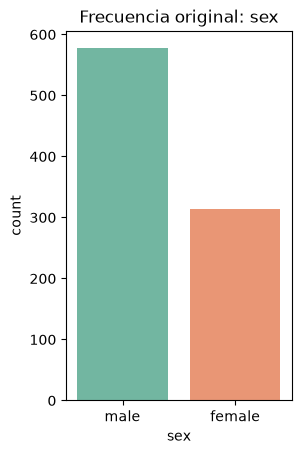

In [7]:
# Frecuencia original
plt.subplot(1, 2, 1)
sns.countplot(data=data, x='sex', palette='Set2')
plt.title('Frecuencia original: sex')


C:\Users\USER\AppData\Local\Temp\ipykernel_24328\4283527152.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='sex_label', palette='Set2')


Text(0.5, 0, 'sex_label')

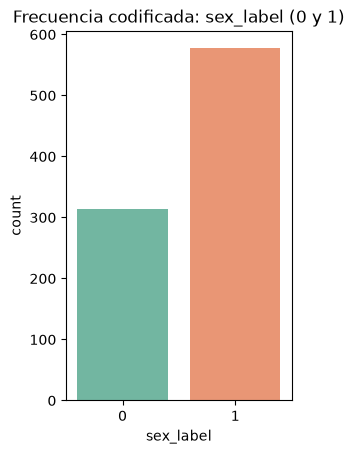

In [8]:
# Frecuencia codificada
plt.subplot(1, 2, 2)
sns.countplot(data=data, x='sex_label', palette='Set2')
plt.title('Frecuencia codificada: sex_label (0 y 1)')
plt.xlabel('sex_label')


In [9]:
plt.tight_layout()
plt.show()
# Usando pandas get_dummies para la columna 'class'
class_encoded = pd.get_dummies(data['class'], prefix='class')


<Figure size 640x480 with 0 Axes>

In [10]:
# Unir al dataframe original para inspeccionar
data_titanic_encoded = pd.concat([data, class_encoded], axis=1)


In [11]:
# Mostrar las primeras filas con las nuevas columnas
print(data_titanic_encoded[['class', 'class_First', 'class_Second', 'class_Third']].head())


   class  class_First  class_Second  class_Third
0  Third        False         False         True
1  First         True         False        False
2  Third        False         False         True
3  First         True         False        False
4  Third        False         False         True


In [12]:
'''
Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.
OneHotEncoder (o codificación binaria/de indicadores) es la opción más segura y recomendada por defecto para la gran mayoría de algoritmos (como Regresión Logística, 
Máquinas de Soporte Vectorial - SVM, Redes Neuronales o KNN).
Evita sesgos de orden como se mencionó antes, la mayoría de los modelos interpretan los números de forma cuantitativa. Si usaras LabelEncoder en una columna como embarked (Southampton, 
Cherbourg, Queenstown), el modelo creería erróneamente que una categoría con valor 2 es "dos veces más grande" o "mejor" que una con valor 1.
Solo se consideraría LabelEncoder (o codificación ordinal) si la variable categórica tiene un orden intrínseco real y medible (por ejemplo: Bajo, Medio, Alto), 
donde numéricamente sí tiene sentido que Alto > Medio > Bajo.
'''

'\nSi quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.\nOneHotEncoder (o codificación binaria/de indicadores) es la opción más segura y recomendada por defecto para la gran mayoría de algoritmos (como Regresión Logística, \nMáquinas de Soporte Vectorial - SVM, Redes Neuronales o KNN).\nEvita sesgos de orden como se mencionó antes, la mayoría de los modelos interpretan los números de forma cuantitativa. Si usaras LabelEncoder en una columna como embarked (Southampton, \nCherbourg, Queenstown), el modelo creería erróneamente que una categoría con valor 2 es "dos veces más grande" o "mejor" que una con valor 1.\nSolo se consideraría LabelEncoder (o codificación ordinal) si la variable categórica tiene un orden intrínseco real y medible (por ejemplo: Bajo, Medio, Alto), \ndonde numéricamente sí tiene sentido que Alto > Medio > Bajo.\n'